In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import pairwise

In [180]:
class Interval:

    def __init__(self, start: float, end: float) -> None:
        if start >= end: raise Exception(f"intervals must be valid and non-empty, found [{start}, {end}[, they all are semi-open [a, b[, a < b")
        self.set_start(start)
        self.set_end(end)

    def __contains__(self, item: float) -> bool:
        return self.start <= item < self.end

    def __repr__(self) -> str:
        return f"[{self.start}, {self.end}["

    def get_start(self) -> float:
        return self.start

    def get_end(self) -> float:
        return self.end

    def set_start(self, new_start: float) -> None:
        self.start = new_start

    def set_end(self, new_end: float) -> None:
        self.end = new_end

    def as_tuple(self) -> tuple[float, float]:
        return (self.get_start(), self.get_end())

In [ ]:
class HullByParts:

    def __init__(self, reference_function: callable[float, float], subfunctions_to_intervals: dict[tuple[float, float], list[Interval]] = {}, function_range: Interval = None):
        self.set_reference_function(reference_function)
        self.set_subfunctionIntervals(subfunctions_to_intervals)
        self.set_range(function_range)

        self.verify_validity()

        self.sanitize_subfunctions()
        self.sanitize_intervals()
        if function_range is None: self.set_range(self.infer_range())

    def __repr__(self):
        res = "defined by :\n"
        for obj in self.get_subfunctionIntervals().items():
            res += str(obj) + "\n"
        res += "on : " + str(self.get_range())

        return res

    def print_dict(self):
        for obj in self.get_subfunctionIntervals().items(): print(obj)


    ############### Callers #########################

    def __call__(self, x: float|list[float]|np.ndarray) -> float|np.ndarray:
        if isinstance(x, float):return self.call_float(x)
        else:                   return self.call_iter(x) 

    def call_iter(self, l) -> np.ndarray:
        return np.array(list(map(lambda x: self.call_float(x), l)))
    
    def call_float(self, x: float) -> float:
        for (slope, x_intercept), intervals in self.get_subfunctionIntervals().items():
            for interval in intervals:
                if x in interval:
                    return self.f(slope * (x - x_intercept))
        raise Exception(f"could not find {x} in the definition set of the function")


    ################# getters, setters, basic adders #####################

    def get_reference_function(self) -> callable[float, float]:
        return self.f
    
    def set_reference_function(self, f: callable[float, float]) -> None:
        self.f = f

    def get_range(self) -> Interval:
        return self.f_range

    def set_range(self, interval: Interval) -> None:
        self.f_range = interval

    def get_subfunctionIntervals(self) -> dict[tuple[float, float], list[Interval]]:
        return self.subfunctionIntervals
    
    def set_subfunctionIntervals(self, dic: dict[tuple[float, float], list[Interval]]) -> None:
        self.subfunctionIntervals = dic
    
    def get_all_intervals(self) -> list[Interval]:
        return [inter for list_inter in self.get_subfunctionIntervals().values() for inter in list_inter]
    
    def add_subfunctionInterval(self, params: tuple[float, float], interval: Interval) -> None:
        if params in self.get_subfunctionIntervals():
            self.subfunctionIntervals[params].append(interval)
        else:
            self.subfunctionIntervals[params] = [interval]

    def add_subfunctionIntervals(self, params: tuple[float, float], interval_list: list[Interval]) -> None:
            if params in self.get_subfunctionIntervals():
                self.subfunctionIntervals[params] += interval_list
            else:
                self.subfunctionIntervals[params] = interval_list


    #################### sanitizers ########################

    def sanitize_subfunctions(self) -> None:
        for (s, x), inters in self.get_subfunctionIntervals().items():
            if s < 0:
                del self.subfunctionIntervals[(s, x)]
                self.subfunctionIntervals[(-s, -x)] = inters

    def sanitize_intervals(self) -> None:
        for inters in self.get_subfunctionIntervals().values():
            inters.sort(key=lambda i: i.get_start())

            i = 0
            while i < len(inters) - 1:
                if inters[i].get_end() == inters[i+1].get_start():
                    inters[i].set_end(inters[i+1].get_end())
                    del inters[i+1]
                else:
                    i += 1

    def infer_range(self) -> Interval:
            all_intervals = self.get_all_intervals()
            return Interval(min(all_intervals, key=lambda i: i.get_start()).get_start(), max(all_intervals, key=lambda i: i.get_end()).get_end())

    @staticmethod
    def sanitize_parameters(params: tuple[float, float]) -> tuple[float, float]:
        s, x = params
        if s < 0:   s, x = -s, -x
        elif s == 0: raise Exception("slope must not be 0, subfunctions must be bijective on R")

        return s, x

    ###################### verifiers #############################

    def verify_slope(self) -> None:
        for (s, _) in self.get_subfunctionIntervals().keys():
            if s == 0:
                raise Exception("slope must not be 0, subfunctions must be bijective on R")

    def verify_defined_on_all_interval(self) -> None:
        sorted_intervals = sorted(self.get_all_intervals(), key = lambda inter: inter.get_start())

        if sorted_intervals != [] and self.get_range() is not None and (self.get_range().get_start() != sorted_intervals[0].get_start() or self.get_range().get_end() != sorted_intervals[-1].get_end()):
            raise Exception("the function must be defined on its entire range, ends do not match")

        for inter1, inter2 in pairwise(sorted_intervals):
            if inter1.get_end() != inter2.get_start(): raise Exception("the function should be defined on the total range it takes values in")

    def verify_validity(self) -> None:
        self.verify_slope()
        self.verify_defined_on_all_interval()


    ##################### complex adders #################
    
    @staticmethod
    def add_intersection(useful_intersections, param, interval, intersect):
        if param not in useful_intersections:
            useful_intersections[param] = {interval: [intersect]}
        elif interval not in useful_intersections[param]:
            useful_intersections[param][interval] = [intersect]
        else:
            useful_intersections[param][interval].append(intersect)

    @staticmethod
    def all_intersections(useful_intersections):
        res = []
        for intervals in useful_intersections.values():
            for (value, _) in intervals.values():
                res.append(value)
        return sorted(res)

    def find_useful_intersections(self, parameters: tuple[float, float]) -> tuple[list, list, list]:
        a, b = parameters
        get_keys = self.get_subfunctionIntervals().keys()

        curbs_sorting_key = lambda k: k[1]
        left_curbs_params = sorted([k for k in get_keys if k[1] < b], key=curbs_sorting_key, reverse=True)
        right_curbs_params = sorted([k for k in get_keys if k[1] > b], key=curbs_sorting_key)
        
        useful_intersections = {}
        considered_curbs = []
        intersection_values = []

        for curbs_params in [left_curbs_params, right_curbs_params]:
            current_min_slope = a
            activate_skip = False
            for params in curbs_params:
                if params[0] >= current_min_slope and activate_skip: continue
                
                considered_curbs.append(params)
                if params[0] <= current_min_slope: 
                    current_min_slope = params[0]
                    if not activate_skip: activate_skip = True

                intervals = self.get_subfunctionIntervals()[params]
                intersections = HullByParts.intersection_points(parameters, params)
                
                for i, intersection in enumerate(intersections):
                    for interval in intervals:
                        if intersection not in interval: continue
                        intersection_values.append(intersection)
                        HullByParts.add_intersection(useful_intersections, params, interval, (intersection, i == 0))
                        
        return useful_intersections, considered_curbs

    def process_previous_curbs(self, parameters, usefull_intersections):
        a, b = parameters
        for params in usefull_intersections:
            for interval in usefull_intersections[params]:
                intersects = usefull_intersections[params][interval]
                if len(intersects) == 1:
                    intersection, side = intersects[0]
                    if side == (intersection < b):  interval.set_end(intersection)
                    else:                           interval.set_start(intersection)

                else: # = 2
                    c, d = params
                    (i_opposite, _), (i_sameside, _) = intersects
                    if c < a:
                        if d < b:
                            if interval.get_end() != i_sameside:
                                self.add_subfunctionInterval(params, Interval(i_sameside, interval.get_end()))
                            interval.set_end(i_opposite)
                        else:
                            if interval.get_start() != i_sameside:
                                self.add_subfunctionInterval(params, Interval(interval.get_start(), i_sameside))
                            interval.set_start(i_opposite)

                    else:
                        if d < b:
                            interval.set_start(i_sameside)
                            interval.set_end(i_opposite)
                        else:
                            interval.set_start(i_opposite)
                            interval.set_end(i_sameside)

    def process_new_intervals(self, parameters, all_intersections):
        _, b = parameters
        intervals = []

        if len([value for value in all_intersections if value < b])%2 == 0:
            value_to_remember = self.get_range().get_start()
        else:
            value_to_remember = None

        for value in all_intersections:
            if value_to_remember is not None:
                intervals.append(Interval(value_to_remember, value))
                value_to_remember = None
            else:
                value_to_remember = value
        if value_to_remember is not None:
            intervals.append(Interval(value_to_remember, self.get_range().get_end()))

        self.add_subfunctionIntervals(parameters, intervals)

        return list(map(lambda inter: inter.as_tuple(), intervals))

    def add_subfunction(self, parameters: tuple[float, float]) -> None:
        a, b = parameters = HullByParts.sanitize_parameters(parameters)
        get_keys = self.get_subfunctionIntervals().keys()
        if b in [x_intercept for _, x_intercept in get_keys]: return#TODO

        useful_intersections, considered_curbs = self.find_useful_intersections((a, b))
        all_intersections = HullByParts.all_intersections(useful_intersections)
        print("intersections :", useful_intersections)
        print("considered :", considered_curbs)
        print("all_intersections :", all_intersections)
        self.process_previous_curbs(parameters, useful_intersections)
        print(self)
        new_intervals = self.process_new_intervals(parameters, all_intersections)
        print(self)

        self.delete_superfluous_intervals(considered_curbs, new_intervals)
        self.sanitize_intervals()

        self.verify_validity()
        
    def delete_superfluous_intervals(self, curbs, new_intervals):
        intervals_to_delete = set()
        for curb in curbs:
            for interval in self.get_subfunctionIntervals()[curb]:
                for start, end in new_intervals:
                    if start < interval.get_start() < end or start < interval.get_end() < end: intervals_to_delete.add((curb, interval))

        for params, interval in intervals_to_delete:
            self.get_subfunctionIntervals()[params].remove(interval)

    @staticmethod
    def intersection_points(g, h):
        g_slope, g_x_inter = g
        h_slope, h_x_inter = h

        opposite_intersect = (g_x_inter*g_slope + h_x_inter*h_slope)/(g_slope + h_slope)
        if g_slope - h_slope == 0:  return [opposite_intersect]

        concurrent_intersect = (g_x_inter*g_slope - h_x_inter*h_slope)/(g_slope - h_slope)
        return [opposite_intersect, concurrent_intersect]
        


In [187]:
def plot_draw(ax, x, hull, draw_value_curves = True):
    ax.set_ylim((0, 4))
    ax.set_xlim((0, 11))

    if draw_value_curves:
        for (slope, x_intercept) in hull.get_subfunctionIntervals():
            func = lambda x: hull.f(slope * (x - x_intercept))
            ax.plot(x, func(x), color = 'black', ls = '-.', alpha = .5)

    ax.plot(x, hull(x), color='green', ls='-', lw=3)

def plot_draw_bis(ax, x, hull: HullByParts, draw_value_curves = True, curbs_to_add = [], y_lim = (0, 4)):
    ax.set_ylim(y_lim)
    ax.set_xlim(hull.get_range().as_tuple())

    if draw_value_curves:
        for (slope, x_intercept) in hull.get_subfunctionIntervals():
            func = lambda x: hull.f(slope * (x - x_intercept))
            ax.plot(x, func(x), color = 'black', ls = '-.', alpha = .5)

    if hull.get_subfunctionIntervals() != {}:
        ax.plot(x, hull(x), color='green', ls='-', lw=10)

    for curb in curbs_to_add:
        hull.add_subfunction(curb)

    if draw_value_curves:
        for (slope, x_intercept) in hull.get_subfunctionIntervals():
            if (slope, x_intercept) in curbs_to_add:
                func = lambda x: hull.f(slope * (x - x_intercept))
                ax.plot(x, func(x), color = 'blue', ls = '-.', alpha = .8)
    
    ax.plot(x, hull(x), color='red', ls='-', lw=3)


In [188]:
def show_iterative_fig(reference_function, function_range, data, draw_value_curves = True, nb_points = 1000, fig_width = 50, fig_height_per_ax = 10, y_limit = (0, 4)):
  x = np.linspace(*function_range, nb_points, endpoint=False)

  subplots = len(data)
  fig, axs = plt.subplots(subplots, 1, figsize=(fig_width, subplots*fig_height_per_ax))

  hull = HullByParts(reference_function, {}, function_range=Interval(*function_range))
  for i, params in enumerate(data):
    plot_draw_bis(axs[i], x, hull, draw_value_curves, curbs_to_add=[params], y_lim=y_limit)
      
  fig.show()

In [ ]:
my_range = (0, 11)
power = lambda e: lambda x: x**e
f = power(2)
data = [(2, 4), (2, 9), (.5, 7), (2, 8), (1, 2), (.5, 10)]
y_lim = (0, 10)

show_iterative_fig(f, my_range, data, y_limit=y_lim)

intersections : {}
considered : []
all_intersections : []
defined by :
on : [0, 11[
defined by :
((1, 2), [[0, 11[])
on : [0, 11[
intersections : {(1, 2): {[0, 11[: [(3.0, True)]}}
considered : [(1, 2)]
all_intersections : [3.0]
defined by :
((1, 2), [[0, 3.0[])
on : [0, 11[
defined by :
((1, 2), [[0, 3.0[])
((1, 4), [[3.0, 11[])
on : [0, 11[
intersections : {(1, 4): {[3.0, 11[: [(4.333333333333333, True), (3.0, False)]}}
considered : [(1, 4), (1, 2)]
all_intersections : [3.0, 4.333333333333333]
defined by :
((1, 2), [[0, 3.0[])
((1, 4), [[3.0, 4.333333333333333[])
on : [0, 11[
defined by :
((1, 2), [[0, 3.0[])
((1, 4), [[3.0, 4.333333333333333[])
((0.5, 5), [[0, 3.0[, [4.333333333333333, 11[])
on : [0, 11[


Exception: the function should be defined on the total range it takes values in

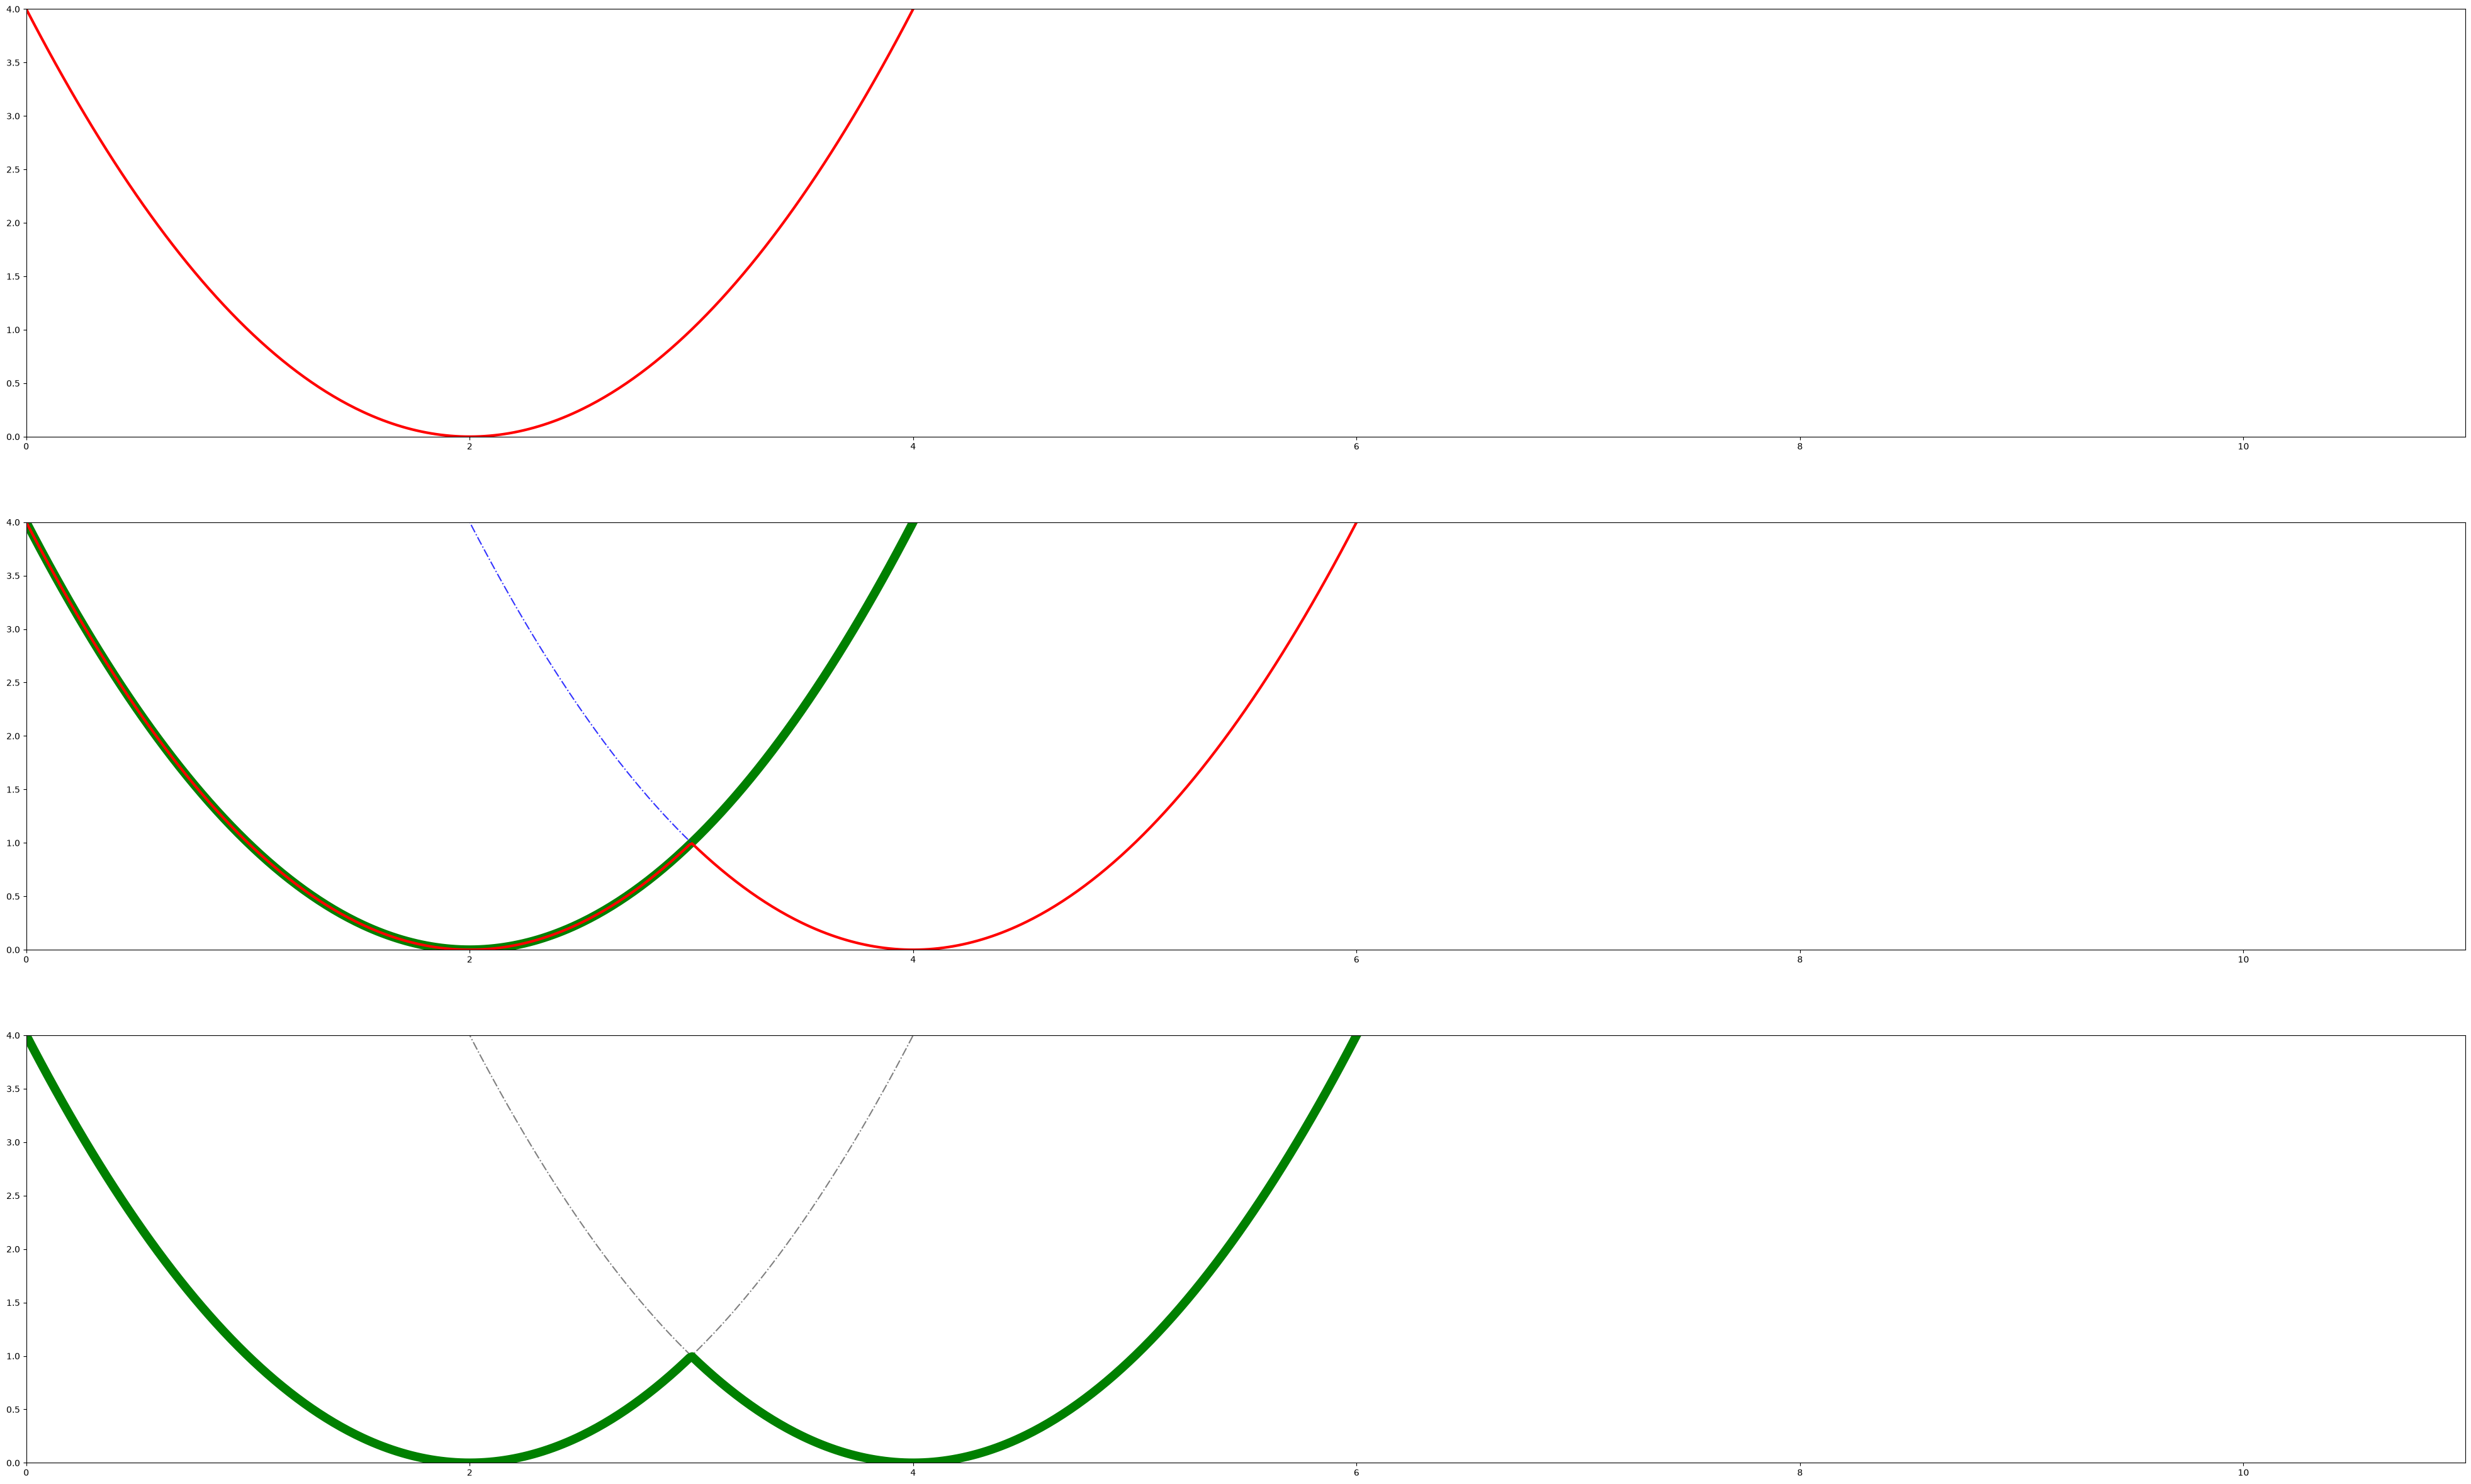

In [197]:
data = [(1, 2), (1, 4), (.5, 5)]

show_iterative_fig(f, my_range, data)